# 10-1 병렬 처리를 위한 새로운 패러다임 - 트랜스포머

본 노트북은 10-1절 본문 예제 [코드 10-1]~[코드 10-6]을 모아 위에서 아래로
실행해 본다. 9장의 날짜 변환기 모델을 파이토치의 `nn.Transformer` 클래스로
다시 만들어, 순환 신경망 기반 Seq2Seq 모델과 어떻게 다른지 확인한다.

다루는 내용
- 학습 가능한 위치 인코딩 `PositionalEncoding` 클래스 ([코드 10-1])
- 트랜스포머 구조의 `DateConverterTransformer` 클래스 ([코드 10-2], [코드 10-3])
- 모델 객체 생성과 학습 ([코드 10-4])
- 인코더/디코더를 분해해 토큰을 생성하는 예측 함수 ([코드 10-5], [코드 10-6])

데이터 생성 함수, 어휘 사전, 데이터셋, 데이터로더, 학습 함수는 9장과
동일하므로 노트북에서 함께 정의한다. 마지막에는 본문에 싣지 않은 멀티헤드
어텐션 헤드별 가중치 시각화 예제도 덧붙인다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# 10장 예제는 PyTorch 기본 패키지만으로 동작한다.
# !pip install -q matplotlib numpy torch

In [2]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [ ]:
# 참고 - 시드 고정과 학습 장치 객체 생성
SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


## 데이터 생성 (9-3절과 동일한 노이즈 데이터)

In [ ]:
# 참고: 데이터 생성 함수 (9-2절과 동일)
from datetime import datetime, timedelta
import random
import string

src_formats = [
    '%d %B %Y',     # 01 February 2026
    '%d %b %Y',     # 01 Feb 2026
    '%B %d, %Y',    # February 01, 2026
    '%b %d, %Y',    # Feb 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

# 시작일(start_date)과 종료일(end_date) 사이의 sample_size개의 무작위 날짜 선택
def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    datetime_list = []
    for _ in range(sample_size):
        days_after = random.randrange(days_between)
        datetime_list.append(start_date + timedelta(days=days_after))
    return datetime_list

# datetime 리스트를 입력 리스트와 정답 리스트로 변환하는 함수
# 입력은 src_formats에 정의된 형식으로, 정답은 'YYYY-M-D' 형식으로 변환
def generate_datepairs(date_list, src_formats=src_formats):
    if len(src_formats) == 0:
        raise ValueError('입력 문자열 템플릿이 비어 있습니다.')
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(date.strftime(src_format))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates

# 노이즈 문자를 추가한 입력 문자열 생성 함수
def add_random_noise(text, max_length=40):
    # 날짜 문자열 앞뒤에 무작위 노이즈 문자를 덧붙여 최대 40자 입력을 만든다.
    noise_chars = (
        string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
    )
    # 앞, 뒤에 추가할 노이즈 문자열
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = random.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(random.choices(noise_chars, k=prefix_length))
    if remaining > 0:
        suffix_length = random.randint(0, remaining)
        suffix = ''.join(random.choices(noise_chars, k=suffix_length))
    return prefix + text + suffix

# 노이즈 문자열을 추가한 입력 날짜 문자열과 정답 날짜 문자열 리스트 생성 함수
def generate_noisy_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(add_random_noise(date.strftime(src_format)))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates

# 노이즈가 섞인 데이터셋 생성
date_list = choice_random_dates(4000)
src_dates, tgt_dates = generate_noisy_datepairs(date_list)
print('노이즈 데이터셋 예시:')
for i in range(4):
    print(f'  {src_dates[i]!r} -> {tgt_dates[i]!r}')

데이터 쌍 수: 4000
예시: 'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'


## 어휘 사전, 데이터셋, 데이터로더 (9-2절과 동일)

글자 단위 어휘 사전과 배치 병합 함수를 9-2절과 같은 방식으로 정의한다.
특수 토큰 `<sos>`, `<eos>`, `<pad>`의 고유 번호도 그대로 사용한다.

In [ ]:
# 참고 - 어휘 사전, 데이터셋, 데이터로더 (9-2절과 동일)
SOS_TOKEN, EOS_TOKEN, PAD_TOKEN = '<sos>', '<eos>', '<pad>'
SOS_IDX, EOS_IDX, PAD_IDX = 0, 1, 2
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, PAD_TOKEN: PAD_IDX}


class Vocab:
    def __init__(self, sequence_list, special_tokens):
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        self.vocab = dict(special_tokens)
        idx_start = len(special_tokens)
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        self.itos = {idx: token for token, idx in self.vocab.items()}

    def encode(self, input_sequence):
        return [self.vocab[token] for token in input_sequence]

    def decode(self, input_ids):
        return [self.itos[idx] for idx in input_ids]

    def __len__(self):
        return len(self.vocab)


class DateDataset(Dataset):
    def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
        self.samples = []
        for src_date, tgt_date in zip(src_dates, tgt_dates):
            src_ids = src_vocab.encode(src_date)
            tgt_ids = [SOS_IDX] + tgt_vocab.encode(tgt_date) + [EOS_IDX]
            self.samples.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_tensors = [torch.LongTensor(s) for s in src_batch]
    tgt_tensors = [torch.LongTensor(t) for t in tgt_batch]
    src_padded = pad_sequence(src_tensors, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_tensors, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded


src_vocab = Vocab(src_dates, special_tokens)
tgt_vocab = Vocab(tgt_dates, special_tokens)
train_set = DateDataset(src_dates[:3000], tgt_dates[:3000], src_vocab, tgt_vocab)
valid_set = DateDataset(src_dates[3000:], tgt_dates[3000:], src_vocab, tgt_vocab)
BATCH_SIZE = 32
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
)
valid_loader = DataLoader(
    valid_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
)
print(f'입력 어휘 사전 크기: {len(src_vocab)}')
print(f'출력 어휘 사전 크기: {len(tgt_vocab)}')
print(f'훈련/검증 데이터셋: {len(train_set)} / {len(valid_set)}')

In [ ]:
# # 참고 - 어휘 사전, 데이터셋, 배치 병합 함수 (9-2절 동일)
# SOS_TOKEN, EOS_TOKEN, PAD_TOKEN = '<sos>', '<eos>', '<pad>'
# SOS_IDX, EOS_IDX, PAD_IDX = 0, 1, 2
# special_tokens = {
#     SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, PAD_TOKEN: PAD_IDX,
# }


# class Vocab:
#     def __init__(self, seqs, special):
#         tokens = set()
#         for s in seqs:
#             tokens.update(s)
#         self.vocab = dict(special)
#         for i, t in enumerate(sorted(tokens)):
#             self.vocab[t] = i + len(special)
#         self.itos = {v: k for k, v in self.vocab.items()}

#     def encode(self, s):
#         return [self.vocab[c] for c in s]

#     def decode(self, ids):
#         return [self.itos[i] for i in ids]

#     def __len__(self):
#         return len(self.vocab)


# class DateDataset(Dataset):
#     def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
#         self.samples = []
#         for s, t in zip(src_dates, tgt_dates):
#             src_ids = src_vocab.encode(s)
#             tgt_ids = [SOS_IDX] + tgt_vocab.encode(t) + [EOS_IDX]
#             self.samples.append((src_ids, tgt_ids))

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         return self.samples[idx]


# def collate_fn(batch):
#     src_batch, tgt_batch = zip(*batch)
#     src_tensors = [torch.LongTensor(s) for s in src_batch]
#     tgt_tensors = [torch.LongTensor(t) for t in tgt_batch]
#     src_padded = pad_sequence(
#         src_tensors, batch_first=True, padding_value=PAD_IDX,
#     )
#     tgt_padded = pad_sequence(
#         tgt_tensors, batch_first=True, padding_value=PAD_IDX,
#     )
#     return src_padded, tgt_padded


# src_vocab = Vocab(src_dates, special_tokens)
# tgt_vocab = Vocab(tgt_dates, special_tokens)
# train_set = DateDataset(
#     src_dates[:3000], tgt_dates[:3000], src_vocab, tgt_vocab,
# )
# valid_set = DateDataset(
#     src_dates[3000:], tgt_dates[3000:], src_vocab, tgt_vocab,
# )

# BATCH_SIZE = 32
# train_loader = DataLoader(
#     train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
# )
# valid_loader = DataLoader(
#     valid_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
# )
# print(f'입력 어휘 사전 크기: {len(src_vocab)} (PAD 포함)')
# print(f'출력 어휘 사전 크기: {len(tgt_vocab)} (PAD 포함)')

입력 어휘 사전 크기: 93 (PAD 포함)
출력 어휘 사전 크기: 14 (PAD 포함)


## [코드 10-1] 학습 가능한 위치 인코딩 `PositionalEncoding`

위치 인덱스(0, 1, 2, ...)를 임베딩 계층으로 벡터화해 토큰 임베딩에 더한다.
`tanh` 활성화로 합산값의 범위를 `[-1, 1]`로 제한해, 작은 규모의 예제가
안정적으로 수렴하도록 돕는다.

In [ ]:
###############################################################################
# 코드 10-1 - 학습 가능한 위치 인코딩 클래스
###############################################################################
class PositionalEncoding(nn.Module):
    def __init__(self, max_length, positional_encoding_dim):
        super().__init__()
        # 0번 위치부터 max_length-1번 위치까지 각각의 위치 인코딩 벡터를 학습
        self.position_embedding = nn.Embedding(
            max_length, positional_encoding_dim,
        )
        # tanh 활성화 - 임베딩 + 위치 인코딩 합산값의 범위를 -1~1로 제한
        self.activation = nn.Tanh()

    def forward(self, token_embedded):
        seq_length = token_embedded.size(1)
        # 0, 1, 2, ... 순서로 위치 인덱스 텐서 생성
        positions = torch.arange(seq_length, device=token_embedded.device)
        # 위치 인코딩 - (seq_length, embed_dim)
        pos_embedded = self.position_embedding(positions)
        # 위치 인코딩과 토큰 임베딩을 더해서 결합 (브로드캐스팅 후 더해짐)
        combined_embedded = token_embedded + pos_embedded
        # 활성화 함수 적용 후 반환
        return self.activation(combined_embedded)

## [코드 10-2], [코드 10-3] `DateConverterTransformer` 클래스

`nn.Transformer`로 인코더와 디코더를 한 번에 만든다. 생성자([코드 10-2])는
입력/정답 토큰 임베딩, 공유 위치 인코딩, 트랜스포머 블록, 분류기로 구성하고,
`forward()`([코드 10-3])는 디코더 입력 준비, 네 종류 마스크 생성, 임베딩
결합, 트랜스포머 호출, 분류기 적용 순으로 동작한다.

In [ ]:
###############################################################################
# 코드 10-2, 10-3 - 트랜스포머 구조의 날짜 변환기 모델
###############################################################################
class DateConverterTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 embed_dim, num_heads, ff_dim, num_layers,
                 max_length, dropout):
        super().__init__()
        # 입력과 정답 토큰 임베딩 계층 - 입력과 정답 임베딩은 별도로 학습
        self.src_embedding = nn.Embedding(
            src_vocab_size, embed_dim, padding_idx=PAD_IDX,
        )
        self.tgt_embedding = nn.Embedding(
            tgt_vocab_size, embed_dim, padding_idx=PAD_IDX,
        )
        # 위치 인코딩 계층 - 입력과 정답의 위치 인코딩은 공유
        self.pos_encoding = PositionalEncoding(max_length, embed_dim)
        # 토큰 임베딩 + 위치 인코딩에 적용하는 드롭아웃 계층
        self.dropout = nn.Dropout(dropout)
        # 트랜스포머 블록 계층 - 인코더 + 디코더
        self.transformer = nn.Transformer(
            d_model=embed_dim, nhead=num_heads,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=ff_dim, dropout=dropout, batch_first=True,
        )
        self.fc = nn.Linear(embed_dim, tgt_vocab_size)

    def forward(self, src, tgt):
        tgt_input = tgt[:, :-1]  # 정답에서 <eos> 제거해 디코더에 입력
        # 입력 패딩 마스크 - <pad> 위치가 True (nn.Transformer 규칙, 9장과 반대)
        src_pad_mask = (src == PAD_IDX)             # (B, src_length)
        # 정답 패딩 마스크
        tgt_pad_mask = (tgt_input == PAD_IDX)       # (B, tgt_length - 1)
        # 인과 마스크 - 미래 토큰을 참조하지 못하도록 -inf 로 채움
        tgt_causal_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_input.size(1), device=src.device,
        )  # (tgt_length - 1, tgt_length - 1)

        # 토큰 임베딩 (입력/정답 별도 계층 사용)
        src_token_embedded = self.src_embedding(src)
        tgt_token_embedded = self.tgt_embedding(tgt_input)
        # 토큰 임베딩과 위치 인코딩 결합 (입력/정답 같은 계층 사용)
        src_embedded = self.pos_encoding(src_token_embedded)
        tgt_embedded = self.pos_encoding(tgt_token_embedded)
        # 특정 토큰 과적합을 피하기 위해 드롭아웃 적용
        src_embedded = self.dropout(src_embedded)
        tgt_embedded = self.dropout(tgt_embedded)

        outputs = self.transformer(
            src_embedded, tgt_embedded,
            tgt_mask=tgt_causal_mask,            # 인과 마스크 - 미래 토큰 차단
            src_key_padding_mask=src_pad_mask,   # 입력 패딩 (인코더 셀프 어텐션)
            tgt_key_padding_mask=tgt_pad_mask,   # 정답 패딩 (디코더 셀프 어텐션)
            memory_key_padding_mask=src_pad_mask,  # 메모리 패딩 (크로스 어텐션)
        )                                # (B, tgt_length - 1, embed_dim)
        return self.fc(outputs)          # (B, tgt_length - 1, tgt_vocab_size)

## 학습 함수와 검증 함수 (본문 비공개, 노트북에서 직접 정의)

9장의 학습 함수와 거의 같지만, LSTM 패킹/언패킹이 필요 없으므로 순차 데이터의
길이 정보를 계산해 전달하는 부분을 걷어냈다. 손실은 `<pad>`를 제외한 토큰
단위 교차 엔트로피를 샘플 가중 평균한다.

In [8]:
# 참고 - 학습 함수 (train_epoch / validation_epoch / train_loop)
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt)                # (B, T-1, vocab_size)
        labels = tgt[:, 1:]                     # <sos> 제거
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
    return loss_sum / sample_size


@torch.no_grad()
def validation_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size, correct_size = 0.0, 0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt)
        labels = tgt[:, 1:]
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
        # 샘플 정확도 - <pad> 위치를 제외하고 모든 토큰이 일치하면 정답
        preds = logits.argmax(dim=-1)
        mask = labels != PAD_IDX
        sample_correct = ((preds == labels) | ~mask).all(dim=1)
        correct_size += sample_correct.sum().item()
    return loss_sum / sample_size, correct_size / sample_size * 100.0


def train_loop(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device, verbose=True):
    """조기 종료 + 최적 모델 복원 학습 루프.

    학습 로그·전체 학습 시간·최적 에포크·학습 곡선은 공통코드컨벤션
    §7.6/§7.7에 따라 common.EpochLogger로 통일한다(검증 손실·정확도가
    있으므로 훈련 손실·검증 손실·정확도(%) 3열). verbose=False면 표·요약
    출력을 접어 두고 로그만 누적하며(어텐션 데모용), 곡선·최적 에포크
    정보는 반환 객체로 그대로 얻을 수 있다.
    """
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)        # 훈련 손실 · 검증 손실 · 정확도(%)
    best_valid_loss = float('inf')
    best_state, best_epoch, counter = None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        valid_loss, valid_acc = validation_epoch(
            model, valid_loader, criterion, device,
        )
        # valid_acc는 이미 백분율 수(0~100)
        if verbose:
            log.row(epoch, train_loss, valid_loss, valid_acc)
        else:
            # 표를 찍지 않고 이력만 누적 (헤더·행 출력 생략)
            with contextlib.redirect_stdout(io.StringIO()):
                log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, counter = epoch, 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    if verbose:
        log.summary(stopped='조기 종료' if stopped else None)
    return {
        'log': log,
        'best_epoch': best_epoch,
        'best_valid_loss': best_valid_loss,
        'stopped': stopped,
    }

## [코드 10-4] 모델 객체 생성과 학습

본문 [코드 10-4]의 하이퍼파라미터로 모델을 만들고 학습한다. 본문은 학습률
상수를 `LEARNING_RATE`로 적었지만, 노트북은 공통 컨벤션의 표준명 `LR`을
사용한다(자세한 내용은 `_book` 노트북 참조).

In [ ]:
###############################################################################
# 코드 10-4 - 모델 객체 생성과 학습
###############################################################################
# 하이퍼파라미터 설정
EMBED_DIM = 64
NUM_HEADS = 4       # 멀티헤드 어텐션의 헤드 수 - EMBED_DIM(d_model)의 약수여야 함
FF_DIM = 128        # 트랜스포머 내부 선형 계층의 크기
NUM_LAYERS = 1      # 사용할 인코더/디코더 기본 블록의 수
MAX_LENGTH = 64     # 처리할 수 있는 최대 순차 데이터 길이
DROPOUT = 0.1       # 트랜스포머와 별도 드롭아웃 계층에 적용할 비율
LR = 1e-3

# 재현을 위한 시드값 초기화
common.set_seed(SEED)

# 모델 객체 생성
model = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    embed_dim=EMBED_DIM, num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 노이즈 데이터 학습 - 충분한 EPOCHS와 참을성 한계 설정
# (노이즈 데이터는 검증 손실이 정체하다 개선되는 구간이 있어 참을성을 넉넉히 둔다)
EPOCHS = 200
PATIENCE = 10
history = train_loop(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True,
)

/home/crapas/work/doc_checker/.venv/lib/python3.14/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/home/crapas/work/doc_checker/.venv/lib/python3.14/site-packages/torch/nn/modules/transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4305       1.0755        0.00%     0:02
  2/200       1.0726       0.9889        0.00%     0:03
  3/200       1.0032       0.9285        0.10%     0:04
  4/200       0.9435       0.8694        0.40%     0:05
  5/200       0.8986       0.8331        0.30%     0:06
  6/200       0.8630       0.8057        0.20%     0:07
  7/200       0.8378       0.7950        0.50%     0:09
  8/200       0.8148       0.7625        0.60%     0:10
  9/200       0.7968       0.7519        1.20%     0:11
 10/200       0.7745       0.7437        1.00%     0:12
 11/200       0.7555       0.7318        0.80%     0:13
 12/200       0.7500       0.7415        1.60%     0:14
 13/200       0.7329       0.7188        1.50%     0:16
 14/200       0.7232       0.7054        1.90%     0:17
 15/200       0.7140       0.7010        1.90%     0:18
 16/200       0.7036       0.6992        2.20%     0:19
 17/200       0.6901       0.6896        2.60%     0:20
 18/2

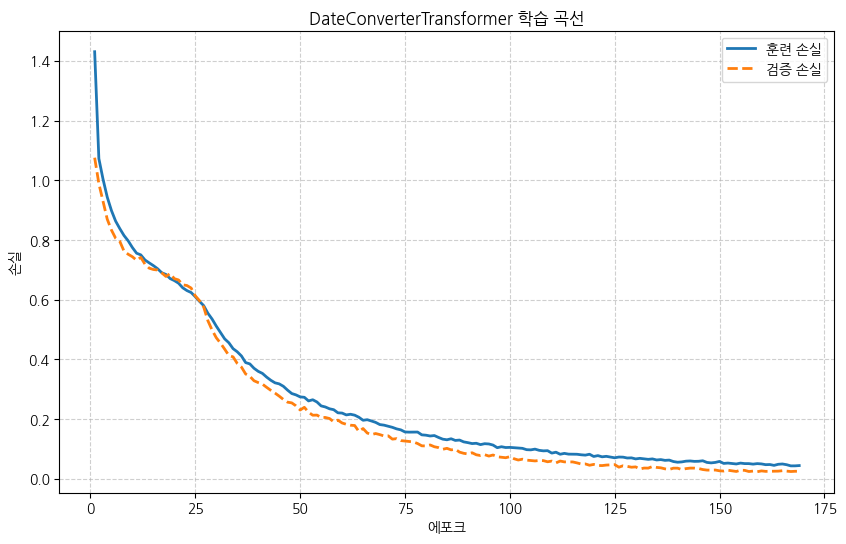

In [10]:
# 참고 - 학습 곡선 시각화 (EpochLogger 내장 plot, §7.7)
history['log'].plot(title='DateConverterTransformer 학습 곡선')

In [ ]:
# 비교 모델 - 헤드가 하나인 크로스 어텐션을 사용하는 모델(num_heads=1)
common.set_seed(SEED)

# 모델 객체 생성
model_single_head = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    embed_dim=EMBED_DIM, num_heads=1, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model_single_head.parameters(), lr=LR)

# 노이즈 데이터 학습 - 충분한 EPOCHS와 참을성 한계 설정
# (노이즈 데이터는 검증 손실이 정체하다 개선되는 구간이 있어 참을성을 넉넉히 둔다)
EPOCHS = 400
PATIENCE = 10
history = train_loop(
    model_single_head, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True,
)

/home/crapas/work/doc_checker/.venv/lib/python3.14/site-packages/torch/nn/modules/transformer.py:143: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = TransformerEncoder(


  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/400       1.4308       1.0810        0.00%     0:01
  2/400       1.0881       0.9992        0.10%     0:02
  3/400       1.0247       0.9546        0.00%     0:03
  4/400       0.9780       0.9054        0.10%     0:04
  5/400       0.9334       0.8712        0.30%     0:05
  6/400       0.9058       0.8450        0.40%     0:06
  7/400       0.8825       0.8338        0.80%     0:07
  8/400       0.8595       0.8003        0.60%     0:08
  9/400       0.8379       0.7764        1.20%     0:09
 10/400       0.8207       0.7600        1.00%     0:10
 11/400       0.7961       0.7436        1.40%     0:11
 12/400       0.7854       0.7338        1.60%     0:12
 13/400       0.7634       0.6967        1.90%     0:13
 14/400       0.7529       0.6701        3.30%     0:14
 15/400       0.7223       0.6181        4.00%     0:15
 16/400       0.6923       0.5575        7.70%     0:16
 17/400       0.6477       0.4811       12.50%     0:17
 18/4

In [ ]:
# 비교 모델 - 헤드가 4, num_layers=2인 크로스 어텐션을 사용하는 모델(num_heads=4, num_layers=2)
common.set_seed(SEED)

# 모델 객체 생성
model_2_layers = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    embed_dim=EMBED_DIM, num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_layers=2, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model_2_layers.parameters(), lr=LR)

# 노이즈 데이터 학습 - 충분한 EPOCHS와 참을성 한계 설정
# (노이즈 데이터는 검증 손실이 정체하다 개선되는 구간이 있어 참을성을 넉넉히 둔다)
EPOCHS = 400
PATIENCE = 10
history = train_loop(
    model_2_layers, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True,
)


  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/400       1.3905       1.0562        0.00%     0:02
  2/400       1.0425       0.9619        0.10%     0:03
  3/400       0.9551       0.8800        0.20%     0:05
  4/400       0.8957       0.8252        0.50%     0:07
  5/400       0.8515       0.8140        0.40%     0:08
  6/400       0.8252       0.7798        0.50%     0:10
  7/400       0.7975       0.7774        0.70%     0:12
  8/400       0.7708       0.7558        1.00%     0:14
  9/400       0.7543       0.7412        1.20%     0:15
 10/400       0.7376       0.7228        1.60%     0:17
 11/400       0.7208       0.7360        1.00%     0:19
 12/400       0.7067       0.7067        1.30%     0:20
 13/400       0.6935       0.7039        1.60%     0:22
 14/400       0.6816       0.7097        2.50%     0:24
 15/400       0.6652       0.6871        2.70%     0:25
 16/400       0.6587       0.6967        2.70%     0:27
 17/400       0.6475       0.6747        2.70%     0:29
 18/4

In [ ]:
# 비교 모델 - 클린 데이터, 헤드가 1인 크로스 어텐션을 사용하는 모델(num_heads=1, 클린 데이터)
# 클린 데이터 생성 (9-3절과 동일)
date_list_clean = choice_random_dates(4000)
src_dates_clean, tgt_dates_clean = generate_datepairs(date_list_clean)

src_vocab_clean = Vocab(src_dates_clean, special_tokens)
tgt_vocab_clean = Vocab(tgt_dates_clean, special_tokens)
train_set_clean = DateDataset(
    src_dates_clean[:3000], tgt_dates_clean[:3000], src_vocab_clean, tgt_vocab_clean,
)
valid_set_clean = DateDataset(
    src_dates_clean[3000:], tgt_dates_clean[3000:], src_vocab_clean, tgt_vocab_clean,
)
train_loader_clean = DataLoader(
    train_set_clean, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
)
valid_loader_clean = DataLoader(
    valid_set_clean, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
)

common.set_seed(SEED)

# 모델 객체 생성
model_clean_data = DateConverterTransformer(
    src_vocab_size=len(src_vocab_clean), tgt_vocab_size=len(tgt_vocab_clean),
    embed_dim=EMBED_DIM, num_heads=1, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model_clean_data.parameters(), lr=LR)

# 노이즈 데이터 학습 - 충분한 EPOCHS와 참을성 한계 설정
# (노이즈 데이터는 검증 손실이 정체하다 개선되는 구간이 있어 참을성을 넉넉히 둔다)
EPOCHS = 400
PATIENCE = 10
history = train_loop(
    model_clean_data, train_loader_clean, valid_loader_clean, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True,
)


  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/400       1.3918       0.7718        2.30%     0:01
  2/400       0.7046       0.3232       35.70%     0:02
  3/400       0.4497       0.1647       58.00%     0:03
  4/400       0.3402       0.0924       74.90%     0:04
  5/400       0.2772       0.0619       82.20%     0:05
  6/400       0.2399       0.0454       84.90%     0:06
  7/400       0.2130       0.0310       91.40%     0:07
  8/400       0.2035       0.0328       89.10%     0:08
  9/400       0.1785       0.0272       91.50%     0:09
 10/400       0.1773       0.0221       92.90%     0:10
 11/400       0.1654       0.0167       95.80%     0:11
 12/400       0.1549       0.0186       94.70%     0:12
 13/400       0.1489       0.0141       95.20%     0:13
 14/400       0.1419       0.0131       95.60%     0:14
 15/400       0.1385       0.0111       96.20%     0:15
 16/400       0.1284       0.0107       96.00%     0:16
 17/400       0.1296       0.0094       96.10%     0:17
 18/4

In [27]:
def get_parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models = [model, model_single_head, model_2_layers, model_clean_data]
model_names = ['4-head', '1-head', '4-head 2-layers', '1-head clean data']
parameter_counts = [get_parameter_count(m) for m in models]

for name, count in zip(model_names, parameter_counts):
    print(f'{name} 모델 파라미터 수: {count:,}')



4-head 모델 파라미터 수: 95,822
1-head 모델 파라미터 수: 95,822
4-head 2-layers 모델 파라미터 수: 179,534
1-head clean data 모델 파라미터 수: 92,622


## [코드 10-5], [코드 10-6] 예측 함수

추론 시에는 트랜스포머 블록을 통째로 쓸 수 없으므로, 인코더를 한 번만
호출해 메모리를 만들고([코드 10-5]) 디코더를 토큰 단위로 반복 호출해 출력을
생성한다([코드 10-6]).

In [ ]:
###############################################################################
# 코드 10-5, 10-6 - 트랜스포머 모델의 예측 함수
###############################################################################
def predict(model, src_text, src_vocab, tgt_vocab, device, max_length=12):
    # src_text: 토큰 고유 번호의 텐서로 변환할 입력 순차 데이터
    model.eval()
    with torch.no_grad():
        src_ids = src_vocab.encode(src_text)
        src_tensor = torch.LongTensor(src_ids).unsqueeze(0).to(device)
        # 토큰 임베딩 + 위치 인코딩
        src_embedded = model.pos_encoding(model.src_embedding(src_tensor))
        # PAD 마스크 - 트랜스포머 계열 클래스는 PAD 위치가 True 인 마스크 사용
        src_pad_mask = (src_tensor == PAD_IDX)
        # 인코더는 한 번만 호출 (추론 시 인코더 출력은 변하지 않는다)
        memory = model.transformer.encoder(
            src_embedded, src_key_padding_mask=src_pad_mask,
        )

        # 인과 마스크 -> 토큰 임베딩 + 위치 인코딩 -> 디코더 -> 분류기 순으로
        # 토큰 하나씩 생성하는 과정을 반복해 출력 순차 데이터 생성
        decoder_input = torch.tensor([[SOS_IDX]], device=device)
        result = []
        for _ in range(max_length):
            tgt_causal_mask = (
                nn.Transformer.generate_square_subsequent_mask(
                    decoder_input.size(1), device=device,
                )
            )
            tgt_embedded = model.pos_encoding(
                model.tgt_embedding(decoder_input),
            )
            decoded_embedded = model.transformer.decoder(
                tgt_embedded, memory,
                tgt_mask=tgt_causal_mask,
                memory_key_padding_mask=src_pad_mask,
            )
            logits = model.fc(decoded_embedded)
            # 지금까지 생성된 토큰 전체를 입력했으므로 마지막 위치의 로짓만 사용
            prediction = logits[:, -1, :].argmax(dim=-1, keepdim=True)  # (1, 1)
            predicted_token = tgt_vocab.decode([prediction.item()])[0]
            if predicted_token == EOS_TOKEN:
                break
            result.append(predicted_token)
            # 생성된 토큰을 지금까지 생성된 토큰에 붙여 다시 입력
            decoder_input = torch.cat([decoder_input, prediction], dim=1)
    return ''.join(result)


# 임의 날짜 하나를 여덟 형식으로 변환 (노이즈 없는 입력과 노이즈 입력 비교)
torch.manual_seed(SEED)
random.seed(SEED)
test_date = choice_random_dates(1) * 8
test_src, test_tgt = generate_datepairs(test_date)
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'정답 날짜 문자열: {test_tgt[0]}')
print('노이즈 없는 날짜 문자열 변환:')
print('  입력 날짜 문자열                         '
      '=> 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(test_src, test_tgt):
    pred = predict(model, src_text, src_vocab, tgt_vocab, device)
    mark = '정답' if pred == tgt_text else '오답'
    print(f'  {src_text:<40s} => {pred} ({mark})')

print('\n노이즈를 추가한 날짜 문자열 변환:')
print('  입력 날짜 문자열                         '
      '=> 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    pred = predict(model, src_text, src_vocab, tgt_vocab, device)
    mark = '정답' if pred == tgt_text else '오답'
    print(f'  {src_text:<40s} => {pred} ({mark})')

정답 날짜 문자열: 2014-9-25
노이즈 없는 날짜 문자열 변환:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  25 September 2014                        => 2014-9-25 (정답)
  25 Sep 2014                              => 2014-9-25 (정답)
  September 25, 2014                       => 2014-9-25 (정답)
  Sep 25, 2014                             => 2014-9-25 (정답)
  09/25/2014                               => 2014-9-25 (정답)
  2014/09/25                               => 2014-9-25 (정답)
  25-09-2014                               => 2014-9-25 (정답)
  2014-09-25                               => 2014-9-25 (정답)

노이즈를 추가한 날짜 문자열 변환:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  cyt25 September 20148}h                  => 2014-9-25 (정답)
  ciu1X@!LNy]^o25 Sep 2014En/Dii=1)#V<H    => 2014-9-25 (정답)
  A3{Grg6&>[]HO-oF7September 25, 2014,52p# => 2014-9-25 (정답)
  Py:9tSep 25, 2014=*ucCxs,]C              => 2014-9-25 (정답)
  S{5mm%V%MZG?mR^[no8109/25/2014H?V<[b     => 2014-9-25 (정답)
  k{%&EAoa##<^Tj3-TrHo.:;2014/09/

## 참고 - 멀티헤드 어텐션 헤드별 가중치 시각화

본문에는 싣지 않은 보조 예제다. 헤드 수 4로 모델을 다시 학습한 뒤, 인코더 첫
계층의 헤드별 셀프 어텐션 가중치를 추출해 격자 히트맵으로 비교한다. 각 헤드가
서로 다른 관계 패턴에 주목한다는 사실을 직접 확인할 수 있다.

In [15]:
# # 참고 - 멀티헤드(4 헤드) 모델 학습 (간단 데모용)
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

# model_mhead = DateConverterTransformer(
#     src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
#     embed_dim=EMBED_DIM, num_heads=4, ff_dim=FF_DIM,
#     num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
# ).to(device)
# optimizer_mhead = optim.Adam(model_mhead.parameters(), lr=LR)
# criterion_mhead = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# # 어텐션 시각화용 보조 학습이므로 표 출력은 접고(verbose=False)
# # EpochLogger가 모은 최적 에포크·검증 손실만 한 줄로 요약한다.
# history_mhead = train_loop(
#     model_mhead, train_loader, valid_loader, criterion_mhead, optimizer_mhead,
#     epochs=EPOCHS, patience=PATIENCE, device=device, verbose=True,
# )
# log_mhead = history_mhead['log']
# print(f'멀티헤드(4) 학습 완료 - 최적 에포크 {history_mhead["best_epoch"]}, '
#       f'최적 검증 손실 {history_mhead["best_valid_loss"]:.4f}')

In [16]:
# 참고 - 헤드별 어텐션 가중치 추출 헬퍼
# nn.MultiheadAttention 은 average_attn_weights=False 일 때
# (B, num_heads, T, S) 형태의 가중치를 반환한다.
def extract_encoder_attention(model, src_tensor):
    """인코더 첫 계층의 셀프 어텐션 헤드별 가중치를 반환."""
    model.eval()
    with torch.no_grad():
        src_embedded = model.pos_encoding(model.src_embedding(src_tensor))
        src_pad_mask = (src_tensor == PAD_IDX)
        layer = model.transformer.encoder.layers[0]
        attn_layer = layer.self_attn
        # need_weights=True, average_attn_weights=False -> (B, H, T, S)
        _, attn_weights = attn_layer(
            src_embedded, src_embedded, src_embedded,
            key_padding_mask=src_pad_mask,
            need_weights=True, average_attn_weights=False,
        )
        return attn_weights[0]  # (num_heads, src_length, src_length)


# 예시 입력으로 헤드별 어텐션 가중치 추출
demo_src = 'Sep 18, 1938'
src_tensor = torch.LongTensor(
    src_vocab.encode(demo_src),
).unsqueeze(0).to(device)
attn_4 = extract_encoder_attention(model, src_tensor).cpu().numpy()
print(f'헤드별 어텐션 가중치 형태: {attn_4.shape} '
      f'(num_heads, src_length, src_length)')

헤드별 어텐션 가중치 형태: (4, 12, 12) (num_heads, src_length, src_length)


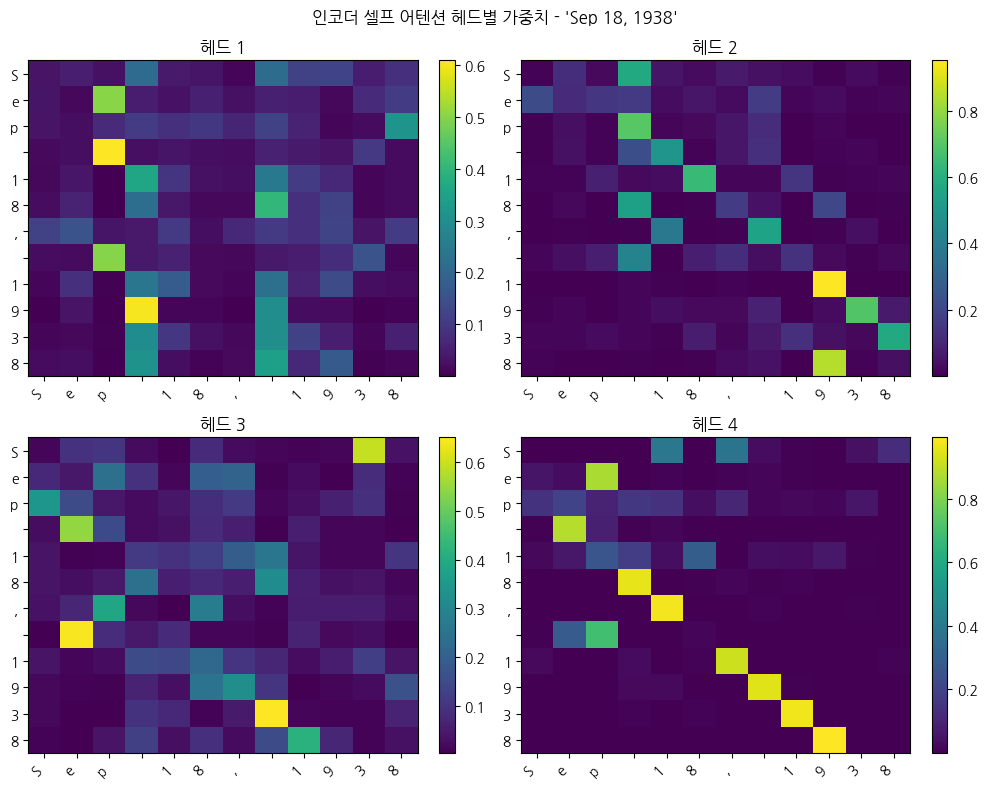

In [17]:
# 참고 - 헤드별 어텐션 가중치 격자 시각화 (matplotlib 직접 사용)
import matplotlib.pyplot as plt

common.set_korean_plot_env()

num_heads = attn_4.shape[0]
src_tokens = list(demo_src)
seq_length = len(src_tokens)
attn_to_show = attn_4[:, :seq_length, :seq_length]  # PAD 영역 제외

cols = 2
rows = (num_heads + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
axes = np.atleast_1d(axes).flatten()
for h in range(num_heads):
    ax = axes[h]
    im = ax.imshow(attn_to_show[h], cmap='viridis', aspect='auto')
    ax.set_xticks(range(seq_length))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticks(range(seq_length))
    ax.set_yticklabels(src_tokens)
    ax.set_title(f'헤드 {h + 1}')
    plt.colorbar(im, ax=ax, fraction=0.046)
for h in range(num_heads, len(axes)):
    axes[h].axis('off')
fig.suptitle(f'인코더 셀프 어텐션 헤드별 가중치 - {demo_src!r}', fontsize=12)
plt.tight_layout()
plt.show()

각 헤드의 가중치 패턴이 서로 다르다는 사실을 확인할 수 있다. 본문은
헤드 수 1로 학습하므로 이 시각화는 노트북에서만 다루는 보조 예제다.

In [18]:
# # 참고 - 멀티헤드(4 헤드) 모델 학습 (간단 데모용)
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

# model_mhead2 = DateConverterTransformer(
#     src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
#     embed_dim=EMBED_DIM, num_heads=4, ff_dim=FF_DIM,
#     num_layers=2, max_length=MAX_LENGTH, dropout=DROPOUT,
# ).to(device)
# optimizer_mhead2 = optim.Adam(model_mhead2.parameters(), lr=LR)
# criterion_mhead2 = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# # 어텐션 시각화용 보조 학습이므로 표 출력은 접고(verbose=False)
# # EpochLogger가 모은 최적 에포크·검증 손실만 한 줄로 요약한다.
# history_mhead2 = train_loop(
#     model_mhead2, train_loader, valid_loader, criterion_mhead2, optimizer_mhead2,
#     epochs=EPOCHS * 2, patience=PATIENCE, device=device, verbose=True,
# )
# log_mhead2 = history_mhead2['log']
# print(f'멀티헤드(4) 학습 완료 - 최적 에포크 {history_mhead2["best_epoch"]}, '
#       f'최적 검증 손실 {history_mhead2["best_valid_loss"]:.4f}')

In [19]:


def train_loop_wu(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device, late_lr, verbose=True):
    """조기 종료 + 최적 모델 복원 학습 루프.

    학습 로그·전체 학습 시간·최적 에포크·학습 곡선은 공통코드컨벤션
    §7.6/§7.7에 따라 common.EpochLogger로 통일한다(검증 손실·정확도가
    있으므로 훈련 손실·검증 손실·정확도(%) 3열). verbose=False면 표·요약
    출력을 접어 두고 로그만 누적하며(어텐션 데모용), 곡선·최적 에포크
    정보는 반환 객체로 그대로 얻을 수 있다.
    """
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)        # 훈련 손실 · 검증 손실 · 정확도(%)
    best_valid_loss = float('inf')
    best_state, best_epoch, counter = None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        if epoch == 11:
            for param_group in optimizer.param_groups:
                param_group['lr'] = late_lr
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        valid_loss, valid_acc = validation_epoch(
            model, valid_loader, criterion, device,
        )
        # valid_acc는 이미 백분율 수(0~100)
        if verbose:
            log.row(epoch, train_loss, valid_loss, valid_acc)
        else:
            # 표를 찍지 않고 이력만 누적 (헤더·행 출력 생략)
            with contextlib.redirect_stdout(io.StringIO()):
                log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, counter = epoch, 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    if verbose:
        log.summary(stopped='조기 종료' if stopped else None)
    return {
        'log': log,
        'best_epoch': best_epoch,
        'best_valid_loss': best_valid_loss,
        'stopped': stopped,
    }

EARLY_LR = 1e-4
LATE_LR = 1e-3


In [20]:
# 참고 - 1헤드 모델 워밍업 학습 (간단 데모용)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
model_wu = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    embed_dim=EMBED_DIM, num_heads=1, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)
optimizer_wu = optim.Adam(model_wu.parameters(), lr=EARLY_LR)
criterion_wu = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

history_wu = train_loop_wu(
    model_wu, train_loader, valid_loader, criterion_wu, optimizer_wu,
    epochs=EPOCHS, patience=PATIENCE, device=device, late_lr=LATE_LR, verbose=True,
)
log_wu = history_wu['log']
print(f'1헤드 모델 워밍업 학습 완료 - 최적 에포크 {history_wu["best_epoch"]}, '
      f'최적 검증 손실 {history_wu["best_valid_loss"]:.4f}')

/home/crapas/work/doc_checker/.venv/lib/python3.14/site-packages/torch/nn/modules/transformer.py:143: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = TransformerEncoder(
/home/crapas/work/doc_checker/.venv/lib/python3.14/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/400       2.2761       1.8282        0.00%     0:01
  2/400       1.6716       1.4029        0.00%     0:02
  3/400       1.4080       1.2608        0.00%     0:03
  4/400       1.2981       1.1933        0.00%     0:04
  5/400       1.2380       1.1485        0.00%     0:05
  6/400       1.1946       1.1149        0.00%     0:06
  7/400       1.1624       1.0918        0.00%     0:07
  8/400       1.1391       1.0722        0.00%     0:08
  9/400       1.1226       1.0582        0.00%     0:09
 10/400       1.1079       1.0448        0.00%     0:10
 11/400       1.0739       0.9791        0.20%     0:11
 12/400       1.0086       0.9247        0.00%     0:12
 13/400       0.9601       0.8721        0.30%     0:13
 14/400       0.9202       0.8565        0.10%     0:14
 15/400       0.8882       0.8278        0.60%     0:15
 16/400       0.8636       0.7888        0.50%     0:16
 17/400       0.8383       0.7886        0.50%     0:17
 18/4

In [21]:
# 참고 - 4헤드 모델 워밍업 학습 (간단 데모용)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model_wu = DateConverterTransformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    embed_dim=EMBED_DIM, num_heads=4, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS, max_length=MAX_LENGTH, dropout=DROPOUT,
).to(device)
optimizer_wu = optim.Adam(model_wu.parameters(), lr=EARLY_LR)
criterion_wu = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# 어텐션 시각화용 보조 학습이므로 표 출력은 접고(verbose=False)
# EpochLogger가 모은 최적 에포크·검증 손실만 한 줄로 요약한다.
history_wu = train_loop_wu(
    model_wu, train_loader, valid_loader, criterion_wu, optimizer_wu,
    epochs=EPOCHS, patience=PATIENCE, device=device, late_lr=LATE_LR, verbose=True,
)
log_wu = history_wu['log']
print(f'1헤드 모델 워밍업 학습 완료 - 최적 에포크 {history_wu["best_epoch"]}, '
      f'최적 검증 손실 {history_wu["best_valid_loss"]:.4f}')

  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/400       2.2750       1.8439        0.00%     0:01
  2/400       1.7036       1.4384        0.00%     0:02
  3/400       1.4279       1.2790        0.00%     0:03
  4/400       1.3051       1.2014        0.00%     0:04
  5/400       1.2320       1.1481        0.00%     0:05
  6/400       1.1842       1.1104        0.00%     0:06
  7/400       1.1527       1.0852        0.00%     0:07
  8/400       1.1279       1.0636        0.00%     0:08
  9/400       1.1058       1.0489        0.00%     0:09
 10/400       1.0912       1.0369        0.00%     0:10
 11/400       1.0535       0.9718        0.00%     0:11
 12/400       0.9784       0.9013        0.00%     0:12
 13/400       0.9192       0.8526        0.20%     0:13
 14/400       0.8758       0.8257        0.40%     0:14
 15/400       0.8450       0.7904        0.50%     0:16
 16/400       0.8200       0.7735        0.20%     0:17
 17/400       0.7947       0.7553        0.60%     0:18
 18/4